In [ ]:
import os
from IPython.display import clear_output


notebook_dir = "/home/balabaevvl/courses/nlp/nlp_course/week11_interpretability"  # notebook's dir

os.chdir(notebook_dir)

GPUs = [
    "GPU-e83bd31b-fcb9-b8de-f617-2d717619413b",
    "GPU-5a9b7750-9f85-49a5-3aae-fe07b1b7661d",
    "GPU-fe2d8dfd-06f2-a5c4-a7fd-4a5f23947005",
    "GPU-0c320096-21ee-4060-8731-826ca2febfab",
    "GPU-baef952c-6609-aace-3b78-e4e07788d5de",
    "GPU-3979d65b-c238-4e9c-0c1c-1aa3f05c56a1",
    "GPU-6c76a2c5-5375-aa06-11d4-0fddfac30e91",
]
os.environ["CUDA_VISIBLE_DEVICES"] = f"{GPUs[3]}"


In [3]:
import os

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"       # !pip install -U hf_transfer
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"    # problems with progress bar

# import shutil
# from huggingface_hub.constants import HF_HUB_CACHE
# cache = os.path.expanduser(HF_HUB_CACHE)
# for d in os.listdir(cache):
#     if d.startswith("models--unsloth--Llama-3.2-3B"):
#         shutil.rmtree(os.path.join(cache, d), ignore_errors=True)
#         print(f"Deleted {d}")


# --- DELETE ALL CACHE ---
# import os, shutil
# from huggingface_hub import scan_cache_dir
# from huggingface_hub.constants import HF_HUB_CACHE

# cache_info = scan_cache_dir()   # Scans everything in ~/.cache/huggingface/hub

# for repo in cache_info.repos:
#     print(f"Deleting cache for: {repo.repo_id}")
#     shutil.rmtree(repo.repo_path, ignore_errors=True)



# Interpretability Seminar

This notebook has two parts:

1. **Attention head visualisation** – we load a GPT‑2 model and visualise its attention patterns.  The goal is to identify phenomena such as attention sinks, copy/induction heads, and positional biases.
2. **Causal interventions and feature steering** – we perform activation patching on the Indirect Object Identification (IOI) task to locate where the model resolves pronoun reference, and we demonstrate simple feature steering through head ablation.

In [84]:
# !pip install torch matplotlib transformer_lens transformers circuitsvis

In [7]:
import torch
import transformers
import circuitsvis as cv
import IPython.display as ipd
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer


model = HookedTransformer.from_pretrained("gpt2")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

clear_output()


In [ ]:
def calculate_attention_heads(layer):
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)

    attention_heads = cache[f"blocks.{layer}.attn.hook_pattern"] # [B, N_heads, Q_len, K_len]

    return attention_heads


def visualise_attention(layer, heads: list[int] | None = None):
    assert layer in list(range(12))

    str_tokens = model.to_str_tokens(tokens)
    pattern = calculate_attention_heads(layer)

    pattern = pattern[0]
    if heads:
        pattern = pattern[heads]

    a = cv.attention.attention_patterns(tokens=str_tokens, attention=pattern)

    return a


text = "When Mary and John went to the store, John gave a drink to Mary."
tokens = model.to_tokens(text).to(device)

layer = 0
ipd.display(visualise_attention(layer))


### Attention heads (1 point)
Your task is to find the following attention heads (and please plot corresponding attention pattern):
- The earliest that attend to first Mary while generating second *
- Attention sink head
- Positional-bias head
- Induction head
- Punctuation-tracking head

In [ ]:
# "The earliest that attend to first Mary while generating second"
ipd.display(visualise_attention(layer=0, heads=[1]))


In [ ]:
# "Attention sink head" - HERE LET'S LOOK NOT AT THE FIRST, BUT AT THE LARGEST

for layer in range(model.cfg.n_layers):
    attention_heads = calculate_attention_heads(layer)
    first_tok_attn = attention_heads[0, ..., :, 0].mean().item()
    print(f"Layer {layer}: avg attention on first token = {first_tok_attn:.2f}")


ipd.display(visualise_attention(layer=7, heads=[2]))


Layer 0: avg attention on first token = 0.30
Layer 1: avg attention on first token = 0.42
Layer 2: avg attention on first token = 0.34
Layer 3: avg attention on first token = 0.53
Layer 4: avg attention on first token = 0.56
Layer 5: avg attention on first token = 0.75
Layer 6: avg attention on first token = 0.69
Layer 7: avg attention on first token = 0.84
Layer 8: avg attention on first token = 0.73
Layer 9: avg attention on first token = 0.80
Layer 10: avg attention on first token = 0.78
Layer 11: avg attention on first token = 0.67


In [ ]:
# "Positional-bias head"
ipd.display(visualise_attention(layer=0, heads=[7]))


In [ ]:
# "Induction head"
ipd.display(visualise_attention(layer=4, heads=[11]))


In [ ]:
# "Punctuation-tracking head"
ipd.display(visualise_attention(layer=1, heads=[1]))



## Activation Patching and Feature Steering (2 points total)

Activation patching is *causal interventions* technique: run the model on a clean input (which exhibits correct behaviour) and a corrupted input (which exhibits incorrect behaviour), then replace a component of the corrupted run with the corresponding activation from the clean run.  If the model’s output is “fixed” by the patch, the replaced component is causal for the behaviour.

In [81]:
# IOI prompts
ioi_clean = "After John and Mary went to the store, Mary gave a bottle of milk to"
ioi_corrupt = "After John and Mary went to the store, John gave a bottle of milk to"

clean_tokens = model.to_tokens(ioi_clean).to(device)
corrupt_tokens = model.to_tokens(ioi_corrupt).to(device)

print(torch.where(clean_tokens != corrupt_tokens)[1])

tensor([10], device='cuda:0')


In [115]:
# Utility to compute logit difference between " John" and " Mary"
def logits_to_logit_diff(logits):
    john_id = model.to_single_token(" John")
    mary_id = model.to_single_token(" Mary")
    final_logits = logits[0, -1, :]
    return float(final_logits[john_id] - final_logits[mary_id])

# Baseline predictions
with torch.no_grad():
    clean_logits = model(clean_tokens)
    corrupt_logits = model(corrupt_tokens)

print("Clean prompt logit diff (John vs Mary):", logits_to_logit_diff(clean_logits))
print("Corrupt prompt logit diff (John vs Mary):", logits_to_logit_diff(corrupt_logits))


Clean prompt logit diff (John vs Mary): 4.276433944702148
Corrupt prompt logit diff (John vs Mary): -2.7375869750976562


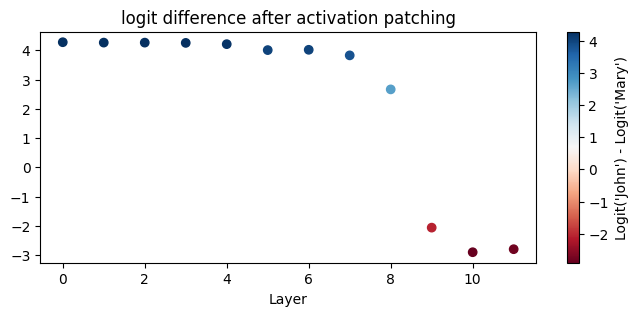

In [116]:
with torch.no_grad():
    _, clean_cache = model.run_with_cache(clean_tokens)
    _, corrupt_cache = model.run_with_cache(corrupt_tokens)

layers = model.cfg.n_layers
logit_diff_effect = torch.zeros((layers, 1))


def patch_resid_hook(value, hook, position: int):
    value[0, position, :] = clean_cache[hook.name][0, position, :]
    return value

def very_smart_decorator(func, position: int):
    def wrapper(*args, **kwargs):
        return func(*args, **kwargs, position=position)
    return wrapper

pos = 10
for L in range(layers):
    # Hook function to replace the residual stream at (layer L)

    h = very_smart_decorator(patch_resid_hook, position=pos)
    patched_logits = model.run_with_hooks(
        corrupt_tokens,
        fwd_hooks=[(f"blocks.{L}.hook_resid_pre", h)]
    )

    # Measure logit difference after patching
    logit_diff_effect[L] = logits_to_logit_diff(patched_logits)

plt.figure(figsize=(8, 3))
plt.scatter(range(12), logit_diff_effect.squeeze().numpy(), cmap='RdBu', c=logit_diff_effect)
plt.colorbar(label="Logit('John') - Logit('Mary')")
plt.xlabel("Layer")
plt.title("logit difference after activation patching")
plt.show()



### Feature steering via head ablation (1 point)

Once we have identified a head or layer that contributes to a behaviour, we can *steer* the model by intervening on it.  For example, ablation removes a head’s influence by zeroing its output.  Conversely, we could amplify a head’s output to bias the model.


In [132]:
def generate_with_hooks(model: HookedTransformer, prompt: str, max_new_tokens: int, hooks)-> str: 
    tokens = model.to_tokens(prompt)
    tokens = tokens.to(model.cfg.device)

    for _ in range(max_new_tokens):
        logits = model.run_with_hooks(
            tokens,
            fwd_hooks=hooks
        )
        next_token = logits[0, -1].argmax().unsqueeze(0)
        tokens = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)

        if next_token == model.tokenizer.eos_token_id:
            break

    return model.to_string(tokens[0, 1:])

def ablate_heads(model: HookedTransformer, heads, prompt: str, max_new_tokens: int = 20)-> str:
    by_layer = {}
    for layer, head_idx in heads:
        by_layer.setdefault(layer, []).append(head_idx)

    hooks = []
    for layer, head_list in by_layer.items():
        def make_hook(head_list=head_list):
            def hook(v, hook):
                # zeroing outputs of all hooked heads
                v[0, :, head_list, :] = 0
                return v
            return hook

        hooks.append((f"blocks.{layer}.attn.hook_v", make_hook()))

    return generate_with_hooks(
        model,
        prompt,
        max_new_tokens=max_new_tokens,
        hooks=hooks
    )


def scale_heads(model: HookedTransformer, heads, scale, prompt: str, max_new_tokens: int = 20)-> str:
    by_layer = {}
    for layer, head_idx in heads:
        by_layer.setdefault(layer, []).append(head_idx)
    hooks = []
    for layer, head_list in by_layer.items():

        def make_hook(head_list=head_list):
            def hook(v, hook):
                # scaling outputs of all hooked heads by scale
                v[0, :, head_list, :] *= scale
                return v
            return hook

        hooks.append((f"blocks.{layer}.attn.hook_v", make_hook()))

    return generate_with_hooks(
        model,
        prompt,
        max_new_tokens=max_new_tokens,
        hooks=hooks
    )

In [ ]:
ioi_prompt = "After John and Mary went to the store, Mary gave a bottle of milk to"
max_new_tokens = 20

NAME_MOVER = [(9,6), (9,9), (10,0)]
NEG_NM     = [(10,7), (11,10)]

print(generate_with_hooks(model, ioi_prompt, max_new_tokens=max_new_tokens, hooks=[]), "\n#---#\n")
print(ablate_heads(model, NAME_MOVER, ioi_prompt, max_new_tokens=max_new_tokens), "\n#---#\n")
print(scale_heads(model, NEG_NM, 7.0, ioi_prompt, max_new_tokens=max_new_tokens), "\n#---#\n")

# >>> lol, Buddha


After John and Mary went to the store, Mary gave a bottle of milk to John. John said, "John, I'm going to have to go to the store and buy 
#---#

After John and Mary went to the store, Mary gave a bottle of milk to John. John said, "I don't know what you're talking about, but I'm going 
#---#

After John and Mary went to the store, Mary gave a bottle of milk to the Buddha.

"I'll tell you what Buddha said," Buddha said. "He said 
#---#



### You may want to experiment here a bit and find more robust setup (for bonus points)
Here are papers that might help you: \
https://arxiv.org/pdf/2211.00593 \
https://arxiv.org/pdf/2310.04625 
